# 房产估值特征价格调价模型

**方法：** 特征价格法（Hedonic Pricing Model）

在 DCF 模型计算出小区居住公允价值的基础上，对楼层、主朝向、南向开间、通透性、装修 5 个房源级特征因子进行调价，
得到针对具体房源的个性化估值。

**定位：** DCF → 小区基准值，调价模型 → 同一小区内具体房源定价

**模型公式：**
```
最终估值 = 基准价 × (1 + r₁) × (1 + r₂) × ... × (1 + r₅)
```


---
## 一、输入参数

修改以下参数后从头运行即可刷新全部输出。


In [1]:
# ============================================================
# 基准价 — DCF 模型输出的公允价值
# ============================================================

base_price = 1_354_580          # 小区居住公允价值（元），从 DCF 模型获取

# ============================================================
# 房源特征输入（房源级因子）
# ============================================================

floor_num = 2                  # 所在楼层
total_floors = 11               # 楼栋总层数
main_orient = "南"              # 主朝向（客厅/主要采光面）：南 / 东南 / 西南 / 东 / 西 / 东北 / 西北 / 北
south_rooms = 2                 # 南向开间数（0~4+）
cross_vent = True               # 通透性：True=南北通透 / False=非通透
decoration = "毛坯"             # 装修：精装 / 简装 / 毛坯

# ============================================================
# 系数表 — 按需调整，每个因子独立
# ============================================================

# 楼层：按相对位置（有电梯高层）
FLOOR_ADJ = {
    "bottom":   -0.06,     # 底层（1层/设备层）
    "low":      -0.02,     # 中低层（< 1/4高度）
    "mid":       0.04,     # 中间层（1/4 ~ 3/4高度）
    "high":      0.01,     # 高层（> 3/4高度，非顶层）
    "top":      -0.04,     # 顶层
}

# 主朝向（客厅/主要采光面）
ORIENT_ADJ = {
    "南":    0.00,
    "东南": -0.01,
    "西南": -0.015,
    "东":   -0.02,
    "西":   -0.025,
    "东北": -0.025,
    "西北": -0.03,
    "北":   -0.03,
}

# 南向开间数
SOUTH_ROOMS_ADJ = {
    0: -0.01,
    1:  0.00,
    2:  0.01,
    3:  0.02,
    4:  0.03,
}

# 通透性
CROSS_VENT_ADJ = {
    True:   0.02,    # 南北通透
    False:  0.00,    # 非通透
}

# 装修
DECO_ADJ = {
    "精装":  0.05,
    "简装":  0.02,
    "毛坯":  0.00,
}

print(f"基准价: {base_price:,.0f} 元")
print("系数表已加载，可直接修改上方参数调整。")


基准价: 1,354,580 元
系数表已加载，可直接修改上方参数调整。


---
## 二、系数明细

当前各特征因子调整率一览，如需覆盖可在上方系数表中修改。


In [2]:
# ============================================================
# 显示当前各项调整系数（仅房源级因子）
# ============================================================

print("=" * 60)
print("  房源级因子调整系数一览")
print("=" * 60)

print("\n--- 楼层 ---")
for k, v in FLOOR_ADJ.items():
    print(f"  {k}: {v*100:+.1f}%")

print("\n--- 主朝向 ---")
for k, v in ORIENT_ADJ.items():
    print(f"  {k}: {v*100:+.1f}%")

print("\n--- 南向开间数 ---")
for k, v in SOUTH_ROOMS_ADJ.items():
    label = f"{k} 间" if k <= 3 else f"{k}+ 间"
    print(f"  {label}: {v*100:+.0f}%")

print("\n--- 通透性 ---")
print(f"  南北通透: {CROSS_VENT_ADJ[True]*100:+.0f}%")
print(f"  非通透:   {CROSS_VENT_ADJ[False]*100:+.0f}%")

print("\n--- 装修 ---")
for k, v in DECO_ADJ.items():
    print(f"  {k}: {v*100:+.0f}%")


  房源级因子调整系数一览

--- 楼层 ---
  bottom: -6.0%
  low: -2.0%
  mid: +4.0%
  high: +1.0%
  top: -4.0%

--- 主朝向 ---
  南: +0.0%
  东南: -1.0%
  西南: -1.5%
  东: -2.0%
  西: -2.5%
  东北: -2.5%
  西北: -3.0%
  北: -3.0%

--- 南向开间数 ---
  0 间: -1%
  1 间: +0%
  2 间: +1%
  3 间: +2%
  4+ 间: +3%

--- 通透性 ---
  南北通透: +2%
  非通透:   +0%

--- 装修 ---
  精装: +5%
  简装: +2%
  毛坯: +0%


---
## 三、单一房源估值

根据当前输入的参数，计算调整后的估值。


In [3]:
# ============================================================
# 调价函数
# ============================================================


def calc_floor_adj(floor, total):
    """计算楼层调整率"""
    if floor == 1:
        return FLOOR_ADJ["bottom"]
    if floor == total:
        return FLOOR_ADJ["top"]
    rel = floor / total
    if rel < 0.25:
        return FLOOR_ADJ["low"]
    if rel <= 0.75:
        return FLOOR_ADJ["mid"]
    return FLOOR_ADJ["high"]


def calc_adjustments(floor, total, orient, south_rm, cross, deco):
    """返回所有调整项的 dict"""
    return {
        "楼层":     calc_floor_adj(floor, total),
        "主朝向":   ORIENT_ADJ.get(orient, 0),
        "南向开间": SOUTH_ROOMS_ADJ.get(south_rm, 0),
        "通透性":   CROSS_VENT_ADJ.get(cross, 0),
        "装修":     DECO_ADJ.get(deco, 0),
    }


def calc_final_value(base, adjustments):
    """乘法模型计算最终估值"""
    val = base
    for name, adj in adjustments.items():
        val *= (1 + adj)
    return val


# ============================================================
# 计算当前参数下的估值
# ============================================================

adj_map = calc_adjustments(floor_num, total_floors, main_orient, south_rooms, cross_vent, decoration)
final_value = calc_final_value(base_price, adj_map)

print("=" * 65)
print("  单一房源估值")
print("=" * 65)
print(f"\n基准价: {base_price:>12,.0f} 元")
print('-' * 50)

for name, adj in adj_map.items():
    amt = base_price * adj
    print(f"  {name}: {adj*100:+>7.2f}%  ({amt:+,.0f} 元)")

print('-' * 50)
print(f"最终估值: {final_value:>12,.0f} 元")


  单一房源估值

基准价:    1,354,580 元
--------------------------------------------------
  楼层: ++-2.00%  (-27,092 元)
  主朝向: +++0.00%  (+0 元)
  南向开间: +++1.00%  (+13,546 元)
  通透性: +++2.00%  (+27,092 元)
  装修: +++0.00%  (+0 元)
--------------------------------------------------
最终估值:    1,367,579 元


---
## 四、可视化

瀑布图展示各因子对估值的贡献。


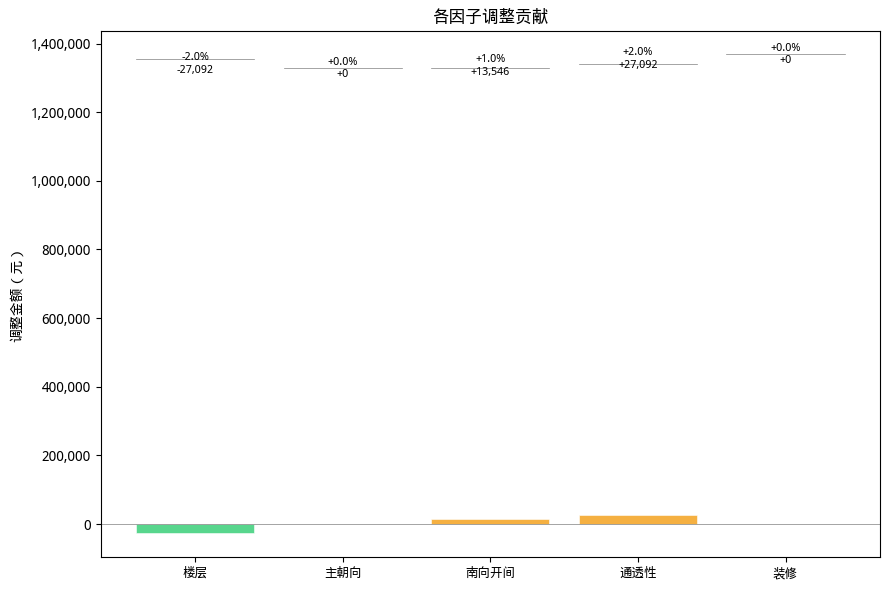

In [4]:
# ============================================================
# 可视化 — 瀑布图（各因子贡献）
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------- 中文字体 ----------
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "Noto Sans CJK SC",
                                    "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ======== 瀑布图 ========
labels = list(adj_map.keys())
rates = list(adj_map.values())
amounts = [base_price * r for r in rates]

cumsum = [base_price]
for a in amounts:
    cumsum.append(cumsum[-1] + a)

colors = []
for r in rates:
    if r >= 0:
        colors.append("#e74c3c" if r > 0.03 else "#f39c12")
    else:
        colors.append("#2ecc71" if r > -0.03 else "#27ae60")

fig, ax1 = plt.subplots(figsize=(9, 6))
bar_container = ax1.bar(range(len(labels)), amounts, color=colors, alpha=0.8, edgecolor="white", linewidth=0.5)
ax1.axhline(y=0, color="gray", linewidth=0.5)

# 连接线
for i in range(len(labels)):
    bot = cumsum[i]
    top = cumsum[i + 1]
    lo, hi = min(bot, top), max(bot, top)
    ax1.plot([i - 0.4, i + 0.4], [bot, bot], color="gray", linewidth=0.5)

# 数值标注
for i, (amt, rate) in enumerate(zip(amounts, rates)):
    y = cumsum[i] + amt / 2
    ax1.text(i, y, f"{rate*100:+.1f}%"  + "\n"  + f"{amt:+,.0f}", ha="center", va="center",
             fontsize=8, fontweight="bold", color="white" if abs(amt) > base_price * 0.03 else "black")

ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("调整金额（元）")
ax1.set_title("各因子调整贡献")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

---
## 五、生成报告

运行以下 Cell，将当前结果输出为 Markdown 报告和/或 PNG 图片。
通过 `report_format` 变量控制：`"markdown"`、`"image"` 或 `"both"`。


Markdown 报告: reports/2026-06-08-调价报告.md


图片报告: reports/2026-06-08-调价报告.png (2 页拼接)


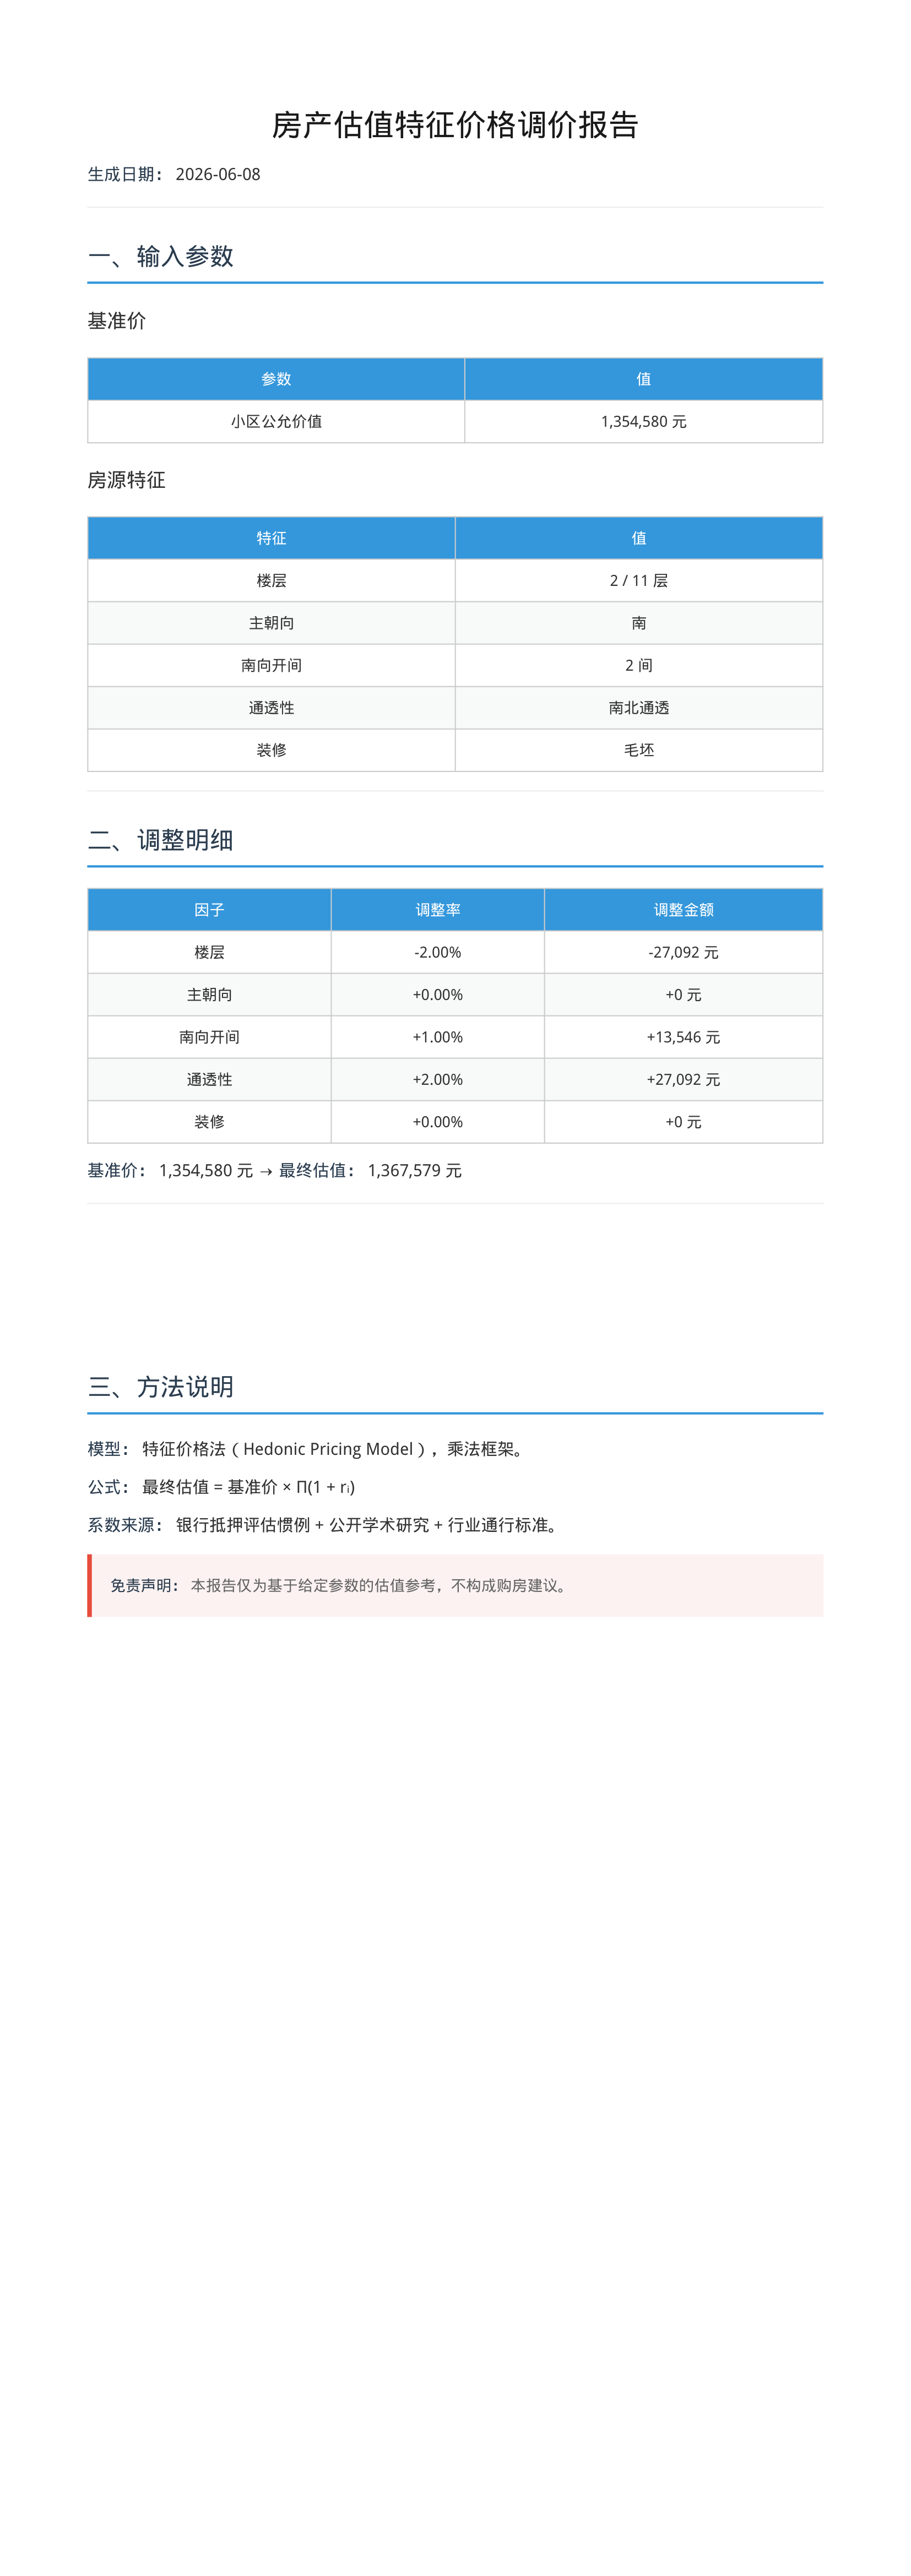

In [5]:
# ============================================================
# 生成估值报告 — Markdown 和/或 PNG 图片输出
# ============================================================

report_format = "both"

import datetime
import os
import markdown as md_lib
import weasyprint
import pymupdf
from PIL import Image as PILImage
from IPython.display import display, Image

today = datetime.date.today().strftime("%Y-%m-%d")
report_dir = "reports"
os.makedirs(report_dir, exist_ok=True)

# ----- 构建报告内容 -----
report = f"""# 房产估值特征价格调价报告

**生成日期：** {today}

---

## 一、输入参数

### 基准价

| 参数 | 值 |
|---|---|
| 小区公允价值 | {base_price:,} 元 |

### 房源特征

| 特征 | 值 |
|---|---|
| 楼层 | {floor_num} / {total_floors} 层 |
| 主朝向 | {main_orient} |
| 南向开间 | {south_rooms} 间 |
| 通透性 | {"南北通透" if cross_vent else "非通透"} |
| 装修 | {decoration} |

---

## 二、调整明细

| 因子 | 调整率 | 调整金额 |
|---|---|---|
"""

for name, adj in adj_map.items():
    amt = base_price * adj
    report += f"| {name} | {adj*100:+.2f}% | {amt:+,.0f} 元 |\n"

report += f"\n**基准价：** {base_price:,} 元 → **最终估值：** {final_value:,.0f} 元\n"

report += """\n---

## 三、方法说明

**模型：** 特征价格法（Hedonic Pricing Model），乘法框架。

**公式：** 最终估值 = 基准价 × Π(1 + rᵢ)

**系数来源：** 银行抵押评估惯例 + 公开学术研究 + 行业通行标准。

> **免责声明：** 本报告仅为基于给定参数的估值参考，不构成购房建议。
"""

# ----- 保存 Markdown -----
if report_format in ("markdown", "both"):
    md_file = f"{report_dir}/{today}-调价报告.md"
    with open(md_file, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"Markdown 报告: {md_file}")

# ----- 生成图片 -----
if report_format in ("image", "both"):
    html_body = md_lib.markdown(report, extensions=["tables", "fenced_code"])

    html_template = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  @page {{ size: A4; margin: 1.8cm; }}
  body {{ font-family: "WenQuanYi Micro Hei", "Noto Sans CJK SC", sans-serif;
          font-size: 11pt; line-height: 1.7; color: #333; }}
  h1 {{ font-size: 20pt; text-align: center; color: #1a1a1a; margin-bottom: 4pt; }}
  h2 {{ font-size: 16pt; color: #2c3e50; border-bottom: 2px solid #3498db;
        padding-bottom: 3pt; margin-top: 18pt; }}
  table {{ border-collapse: collapse; width: 100%; margin: 8pt 0; font-size: 10pt; }}
  th, td {{ border: 1px solid #ccc; padding: 5pt 8pt; text-align: center; }}
  th {{ background-color: #3498db; color: white; font-weight: bold; }}
  tr:nth-child(even) {{ background-color: #f8f9fa; }}
  strong {{ color: #2c3e50; }}
  blockquote {{ border-left: 4px solid #e74c3c; margin: 10pt 0; padding: 6pt 12pt;
               background-color: #fdf2f2; color: #666; font-size: 10pt; }}
  hr {{ border: none; border-top: 1px solid #eee; margin: 12pt 0; }}
  p {{ margin: 6pt 0; }}
</style>
</head>
<body>
{html_body}
</body>
</html>"""

    img_file = f"{report_dir}/{today}-调价报告.png"
    pdf_data = weasyprint.HTML(string=html_template).write_pdf()
    doc = pymupdf.open("pdf", pdf_data)
    pages = [doc[i].get_pixmap(dpi=200) for i in range(doc.page_count)]
    total_h = sum(p.height for p in pages)
    canvas = PILImage.new("RGB", (pages[0].width, total_h))
    y = 0
    for p in pages:
        img = PILImage.frombytes("RGB", (p.width, p.height), p.samples)
        canvas.paste(img, (0, y))
        y += p.height
    canvas.save(img_file)
    num_pages = doc.page_count
    doc.close()
    print(f"图片报告: {img_file} ({num_pages} 页拼接)")

    display(Image(filename=img_file))